In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('sales_datasets.csv')
df.head()

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,order_date
0,ORD_0019634,200.0,60000,0,700000,Seal / Baut / Roof,1.0,Selesai,Tidak dibatalkan,Kargo-JNE Trucking (JTR),Online Payment,KAB. GRESIK,JAWA TIMUR,"Rp106,500","Rp100,000","Rp2,684,500","Rp206,500",9/28/2024 21:41,9/28/2024
1,ORD_0011837,256.0,51200,0,384000,Nampan / Tray,1.0,Batal,Dibatalkan oleh Pembeli. Alasan: Perlu menguba...,Kargo,online payment,KOTA PALEMBANG,SUMATERA SELATAN,Rp-,Rp-,Rp-,"Rp246,201",3/25/2024 9:54,NaN
2,ORD_0011838,256.0,51200,0,384000,Nampan / Tray,1.0,Selesai,Tidak dibatalkan,Kargo-J&T Cargo,Online Payment,KOTA PALEMBANG,SUMATERA SELATAN,"Rp146,201","Rp100,000","Rp1,325,801","Rp246,201",3/25/2024 10:04,3/25/2024
3,ORD_0012214,242.0,48400,0,302500,Nampan / Tray,1.0,Batal,Dibatalkan oleh Pembeli. Alasan: Perlu menguba...,Kargo,Online Payment,KOTA PALEMBANG,SUMATERA SELATAN,Rp-,Rp-,Rp-,"Rp236,801",3/10/2025 7:41,3/10/2025
4,ORD_0012216,242.0,48400,0,302500,Nampan / Tray,1.0,Selesai,Tidak dibatalkan,Kargo-JNE Trucking (JTR),Online Payment,KOTA PALEMBANG,SUMATERA SELATAN,"Rp135,801","Rp101,000","Rp1,403,301","Rp236,801",3/10/2025 7:46,3/10/2025


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18868 entries, 0 to 18867
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   order_id                              18868 non-null  object 
 1   total_qty                             18585 non-null  float64
 2   total_weight_gr                       18868 non-null  int64  
 3   total_returned_qty                    18868 non-null  int64  
 4   Total Diskon                          18868 non-null  int64  
 5   product_categories                    18868 non-null  object 
 6   num_product_categories                17502 non-null  float64
 7   Status Pesanan                        17502 non-null  object 
 8   Alasan Pembatalan                     17347 non-null  object 
 9   Opsi Pengiriman                       17347 non-null  object 
 10  Metode Pembayaran                     17089 non-null  object 
 11  Kota/Kabupaten 

In [5]:
df.isnull().sum()

order_id                                   0
total_qty                                283
total_weight_gr                            0
total_returned_qty                         0
Total Diskon                               0
product_categories                         0
num_product_categories                  1366
Status Pesanan                          1366
Alasan Pembatalan                       1521
Opsi Pengiriman                         1521
Metode Pembayaran                       1779
Kota/Kabupaten                          1521
Provinsi                                1521
 Ongkos Kirim Dibayar oleh Pembeli      1521
 Estimasi Potongan Biaya Pengiriman     1521
 Total Pembayaran                       1521
 Perkiraan Ongkos Kirim                 1521
Waktu Pesanan Dibuat                    1521
order_date                              1699
dtype: int64

In [6]:
# IDENTIFIKASI MASALAH

total_data = len(df)
total_selesai = (df['Status Pesanan'] == 'Selesai').sum()
total_batal = (df['Status Pesanan'] == 'Batal').sum()
batal_rate = total_batal / total_data * 100

print(f"Total transaksi: {total_data}")
print(f"Total transaksi selesai: {total_selesai}")
print(f"Total transaksi gagal: {total_batal}")
print(f"Rate transaksi gagal: {round(batal_rate, 2)}%")

Total transaksi: 18868
Total transaksi selesai: 14877
Total transaksi gagal: 2387
Rate transaksi gagal: 12.65%


In [7]:
# CLEANING DATASET

# HAPUS SPASI BERLEBIH (TRIM)
df.columns = df.columns.str.strip()

# UBAH KOLOM DENGAN MATA UANG RUPIAH DARI STR KE FLOAT
num_cols = ["Ongkos Kirim Dibayar oleh Pembeli", "Estimasi Potongan Biaya Pengiriman", "Total Pembayaran", "Perkiraan Ongkos Kirim"]

def parse_rupiah(s):
    if pd.isna(s):
        return np.nan
    cleaned = (str(s).replace('Rp', '').replace(',','')
                    .replace('.', '').replace(' ','')
                    .replace('-','0').strip())
    try:
        return float(cleaned)
    except ValueError:
        return np.nan
    
for col in num_cols:
    df[col] = df[col].apply(parse_rupiah)
    n_null = df[col].isna().sum()

# KONVERSI TANGGAL
df['Waktu Pesanan Dibuat'] = pd.to_datetime(df['Waktu Pesanan Dibuat'], errors='coerce')
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# NORMALISASI METODE PEMBAYARAN
payment_map = {
    'COD (Bayar di Tempat)' : 'COD',
    'Cash On Delivery'       : 'COD',
    'Saldo ShopeePay'        : 'ShopeePay',
    'saldo shopeepay'        : 'ShopeePay',
    'ShopeePay'              : 'ShopeePay',
    'SPayLater'              : 'SPay Later',
    'SPAY LATER'             : 'SPay Later',
    'Online Payment'         : 'Online Payment',
    'online payment'         : 'Online Payment',
    'OnlinePayment'          : 'Online Payment',
    'SeaBank Bayar Instan'   : 'SeaBank',
    'Kartu Kredit/Debit'     : 'Kartu Kredit/Debit',
    'Cicilan Kartu Kredit'   : 'Kartu Kredit/Debit',
    'BCA OneKlik'            : 'BCA OneKlik',
    'Indomaret/i.Saku'       : 'Minimarket',
    'Alfamart/Alfamidi/Dan+Dan': 'Minimarket',
    'Mitra Shopee'           : 'Mitra Shopee',
    'Pembayaran dibebaskan'  : 'Lainnya',
}

df['Metode Pembayaran'] = (df['Metode Pembayaran']
                           .map(payment_map)
                           .fillna(df['Metode Pembayaran']))

# NORMALISASI OPSI PENGIRIMAN
def simplify_shipping(s):
    if pd.isna(s): return np.nan
    s = str(s).upper()
    if 'HEMAT' in s: return 'Hemat'
    if 'REGULER' in s or 'STANDARD' in s: return 'Reguler'
    if 'SAME DAY' in s or 'SAMEDAY' in s: return 'Same Day'
    if 'INSTANT' in s: return 'Instant'
    if 'NEXT DAY' in s: return 'Next Day'
    if 'KARGO' in s or 'CARGO' in s: return 'Kargo'
    if 'AGEN' in s: return 'Agen'
    if 'GOSEND' in s: return 'GoSend'
    if 'GRAB' in s: return 'GrabExpress'
    return 'Lainnya'
df['Opsi Pengiriman Simplify'] = df['Opsi Pengiriman'].apply(simplify_shipping)

# AKTOR PEMBATALAN
def get_actor(r):
    if pd.isna(r): return 'Unknown'
    if 'Pembeli' in r: return 'Pembeli'
    if 'sistem' in r: return 'Sistem'
    if 'Penjual' in r: return 'Penjual'
    if 'Tidak dibatalkan' in r: return 'Tidak Batal'
    return 'Lainnya'
df['Cancel Actor'] = df['Alasan Pembatalan'].apply(get_actor)

# SEDERHANAKAN ALASAN PEMBATALAN
def simplify_reason(r):
    if pd.isna(r): return 'Unknown'
    r = str(r)
    if 'Tidak dibatalkan'    in r: return 'Tidak Batal'
    if 'berubah pikiran'     in r: return 'Berubah Pikiran'
    if 'Ubah Pesanan'        in r: return 'Ubah Pesanan'
    if 'delivery address'    in r: return 'Ubah Alamat'
    if 'alamat pengiriman'   in r: return 'Ubah Alamat'
    if 'mengubah pesanan'    in r: return 'Ubah Pesanan'
    if 'belum dibayar'       in r: return 'Belum Dibayar'
    if 'Pengiriman gagal'    in r: return 'Pengiriman Gagal'
    if 'gagal mengirimkan'   in r: return 'Penjual Terlambat'
    if 'tidak mengatur'      in r: return 'Penjual Terlambat'
    if 'responsif'           in r: return 'Penjual Tidak Responsif'
    if 'Voucher'             in r: return 'Ubah Voucher'
    if 'pembayaran sulit'    in r: return 'Pembayaran Sulit'
    if 'lebih murah'         in r: return 'Harga Lebih Murah'
    if 'hilang'              in r: return 'Paket Hilang'
    return 'Lainnya'
df['Alasan Simplify'] = df['Alasan Pembatalan'].apply(simplify_reason)



In [8]:
# TAMBAHKAN KOLOM BULAN, HARI DAN JAM UNTUK KEBUTUHAN ANALISA
df['order_month'] = df['Waktu Pesanan Dibuat'].dt.month
df['oder_year'] = df['Waktu Pesanan Dibuat'].dt.year
df['order_day'] = df['Waktu Pesanan Dibuat'].dt.day_name()
df['order_hour'] = df['Waktu Pesanan Dibuat'].dt.hour

## Problem Identification

In [9]:
# TOTAL PESANAN
total_pesanan = len(df)

# PESANAN SELESAI
pesanan_selesai = len(df[df['Status Pesanan']=='Selesai'])

# PESANAN GAGAL/DIBATALKAN
pesanan_dibatalkan = len(df[df['Status Pesanan']=='Batal'])

# LAINNYA
pesanan_status_lainnya = (total_pesanan - pesanan_selesai - pesanan_dibatalkan)

print(f"Total Pesanan: {total_pesanan}")
print(f"Status Pesanan Selesai: {pesanan_selesai} {round(pesanan_selesai/total_pesanan*100, 2)}%")
print(f"Status Pesanan Dibatalakn: {pesanan_dibatalkan} {round(pesanan_dibatalkan/total_pesanan*100, 2)}%")
print(f"Status Pesanan Lainnya: {pesanan_status_lainnya}")

Total Pesanan: 18868
Status Pesanan Selesai: 14877 78.85%
Status Pesanan Dibatalakn: 2387 12.65%
Status Pesanan Lainnya: 1604


## Distribusi Status Pesanan

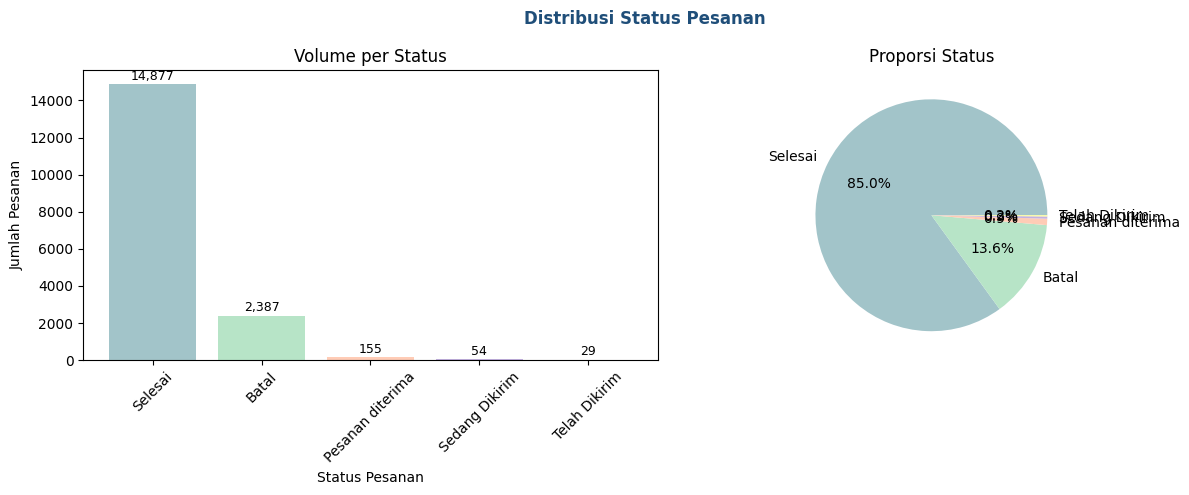

In [10]:
status_counts = df['Status Pesanan'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle("Distribusi Status Pesanan", fontweight='bold', color='#1F4E79')
axes[0].bar(status_counts.index, status_counts.values, color=['#A2C4C9', '#B7E4C7', '#FFCCB6', '#C3B1E1', '#FDFD96'])
axes[0].set_title('Volume per Status')
axes[0].set_xlabel('Status Pesanan')
axes[0].set_ylabel('Jumlah Pesanan')
axes[0].tick_params(axis='x', labelrotation=45)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
    
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#A2C4C9', '#B7E4C7', '#FFCCB6', '#C3B1E1', '#FDFD96'],
            startangle=0)
axes[1].set_title('Proporsi Status')

plt.tight_layout()
plt.show()

## Aktor Pembatalan

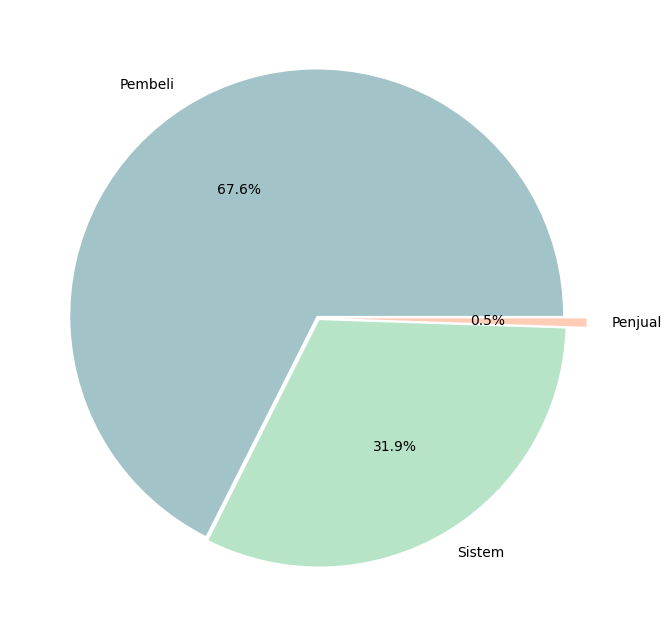

In [11]:
cancel_df = df[df['Status Pesanan'] == 'Batal']
actor_count = cancel_df['Cancel Actor'].value_counts()

plt.figure(figsize=(12, 8))
explode = [.01, .01, .09]
plt.pie(actor_count.values, labels=actor_count.index, autopct='%1.1f%%',
        colors=['#A2C4C9', '#B7E4C7', '#FFCCB6'], explode=explode)
plt.show()

## Alasan Pembatalan

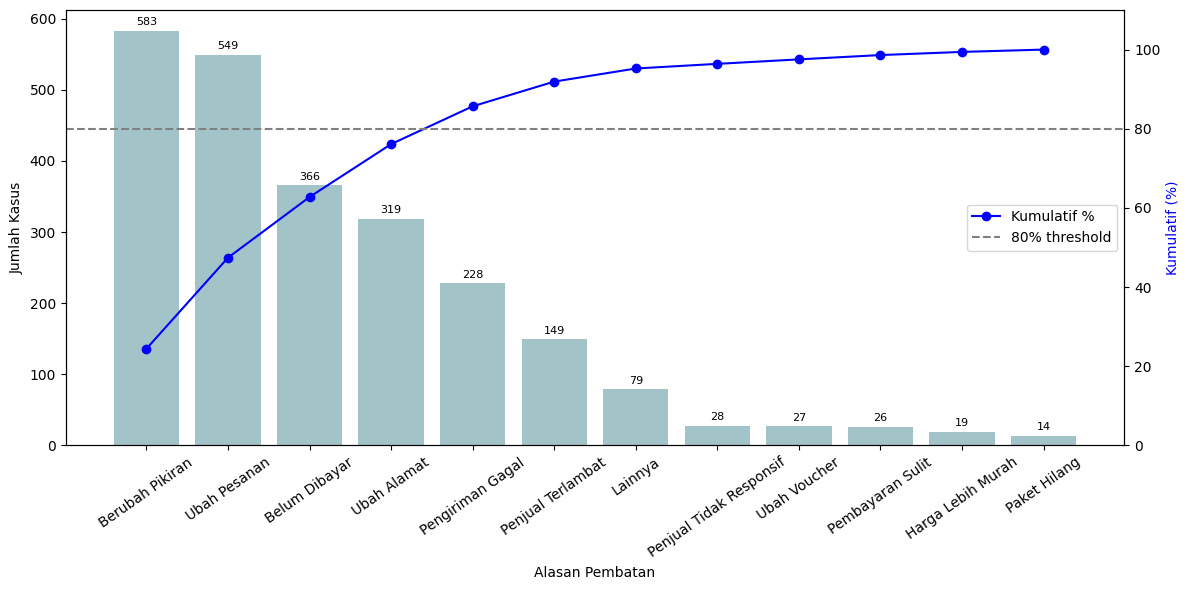

In [12]:
reasons_count = cancel_df[cancel_df['Alasan Simplify'] != 'Tidak Batal']['Alasan Simplify'].value_counts()
cumulative = reasons_count.cumsum() / reasons_count.sum() * 100
# print(pd.DataFrame({'Jumlah':reasons_count,
#                     'Kumulatif':cumulative.round(1)}))

fig, ax1 = plt.subplots(figsize=(12, 6))
bars = plt.bar(reasons_count.index, reasons_count.values, color='#A2C4C9')
ax1.tick_params(axis='x', rotation=35)
ax1.set_xlabel('Alasan Pembatan')
ax1.set_ylabel('Jumlah Kasus')
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=8
    )

ax2 = ax1.twinx()
ax2.plot(range(len(cumulative)), cumulative.values, color='blue', marker='o', label='Kumulatif %')
ax2.axhline(80, color='gray', linestyle='--', label='80% threshold')
ax2.set_ylabel('Kumulatif (%)', color='blue')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

In [13]:
df['is_cancel'] = (df['Status Pesanan'] == 'Batal').astype(int)



In [14]:
pay_df = df[df['Metode Pembayaran'].notna()].groupby(['Metode Pembayaran', 'is_cancel']).size().unstack()
pay_df.columns = ['Tidak Batal', 'Batal']

pay_df['Total'] = pay_df.sum(axis=1)
pay_df['Cancel Rate'] = (pay_df['Batal'] / pay_df['Total'] * 100).round(1)
pay_df = pay_df.sort_values('Cancel Rate', ascending=False)
pay_df

,Tidak Batal,Batal,Total,Cancel Rate
Metode Pembayaran,,,,
Mitra Shopee,NaN,1.0,1.0,100.0
Minimarket,38.0,33.0,71.0,46.5
BCA OneKlik,2.0,1.0,3.0,33.3
Online Payment,2045.0,473.0,2518.0,18.8
SPay Later,971.0,193.0,1164.0,16.6
COD,8463.0,1339.0,9802.0,13.7
SeaBank,435.0,63.0,498.0,12.7
Kartu Kredit/Debit,153.0,20.0,173.0,11.6
ShopeePay,2610.0,236.0,2846.0,8.3


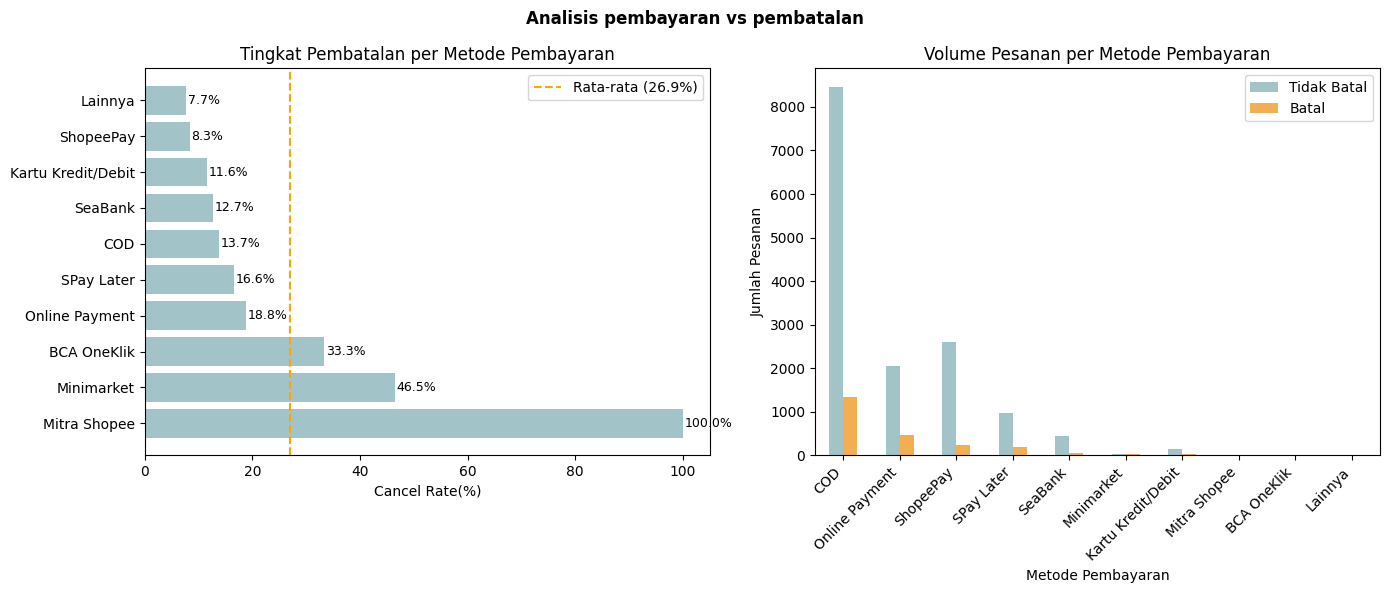

In [51]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
plt.suptitle("Analisis pembayaran vs pembatalan", fontweight='bold')

axes[0].barh(pay_df.index, pay_df['Cancel Rate'], color='#A2C4C9')
axes[0].axvline(pay_df['Cancel Rate'].mean(), color='orange', linestyle='--', label=f"Rata-rata ({pay_df['Cancel Rate'].mean():.1f}%)")
axes[0].set_title("Tingkat Pembatalan per Metode Pembayaran")
axes[0].set_xlabel("Cancel Rate(%)")
axes[0].legend()
for i, v in enumerate(pay_df['Cancel Rate']):
    axes[0].text(v + .3, i, f'{v:.1f}%', va='center', fontsize=9)

pay_vol = pay_df[['Tidak Batal', 'Batal']].sort_values('Batal', ascending=False)
pay_vol[['Tidak Batal', 'Batal']].plot(kind='bar', ax=axes[1],color=['#A2C4C9','#F4AE52'])
axes[1].set_title("Volume Pesanan per Metode Pembayaran")
axes[1].set_xlabel("Metode Pembayaran")
axes[1].set_ylabel("Jumlah Pesanan")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [16]:
tren = df[df['order_date'].notna()].groupby([df['order_date'].dt.to_period('M'), 'is_cancel']).size().unstack(fill_value=0)
tren.columns = ['Tidak Batal', 'Batal']
tren['Cancel Rate'] = (tren['Batal'] / tren.sum(axis=1) * 100).round(1)
tren.index = tren.index.astype(str)
tren

,Tidak Batal,Batal,Cancel Rate
order_date,,,
2023-01,1,0,0.0
2023-04,1,0,0.0
2023-05,1,0,0.0
2023-08,0,1,100.0
2023-09,0,2,100.0
2023-10,1,0,0.0
2023-12,311,81,20.7
2024-01,332,54,14.0
2024-02,292,56,16.1


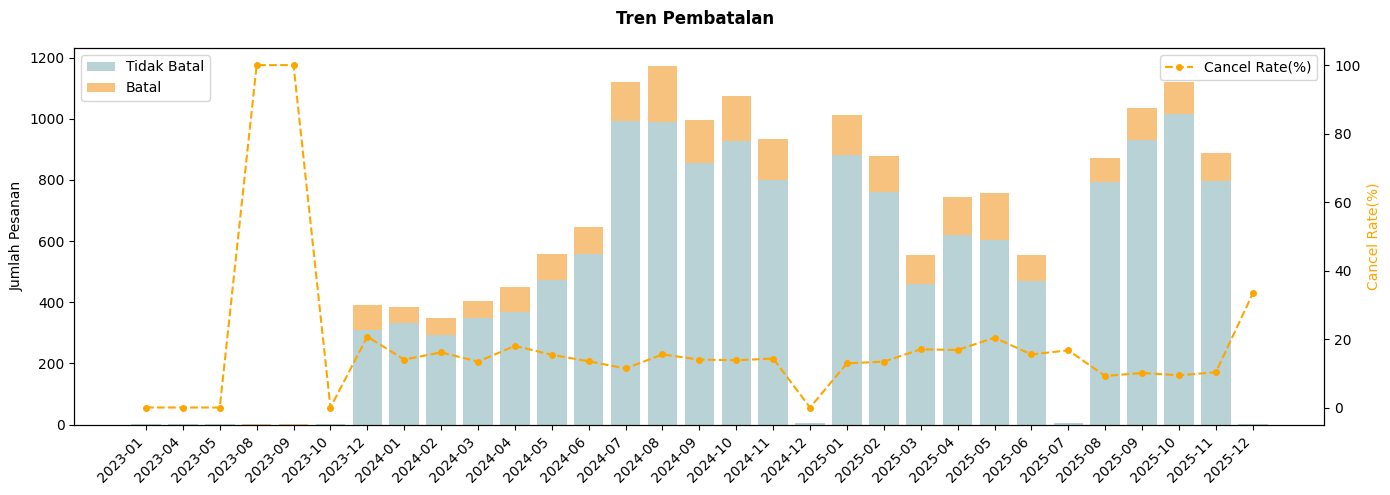

In [58]:
fig, ax1 = plt.subplots(figsize=(14,5))
fig.suptitle("Tren Pembatalan", fontweight="bold")
ax1.bar(tren.index, tren['Tidak Batal'], label='Tidak Batal', alpha=.75, color='#A2C4C9')
ax1.bar(tren.index, tren['Batal'], bottom=tren['Tidak Batal'], label='Batal', alpha=.75, color='#F4AE52')
ax1.set_ylabel("Jumlah Pesanan")
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(tren.index, tren['Cancel Rate'], label='Cancel Rate(%)', color='orange', linestyle='--', marker='o', markersize=4)
ax2.set_ylabel('Cancel Rate(%)', color='orange')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [18]:
prov_cancel = df[df['Provinsi'].notna()].groupby('Provinsi')['is_cancel'].agg(['sum', 'count'])
prov_cancel.columns = ['Batal', 'Total Transaksi']
prov_cancel['Cancel Rate'] = (prov_cancel['Batal'] / prov_cancel.sum(axis=1) * 100).round(1)
prov_cancel = prov_cancel.sort_values('Batal', ascending=False).head(10)
prov_cancel

,Batal,Total Transaksi,Cancel Rate
Provinsi,,,
JAWA BARAT,652,5656,10.3
BANTEN,349,2951,10.6
DKI JAKARTA,307,2458,11.1
JAWA TIMUR,203,1331,13.2
JAWA TENGAH,163,1209,11.9
SUMATERA SELATAN,89,539,14.2
LAMPUNG,56,403,12.2
RIAU,54,273,16.5
SUMATERA UTARA,48,255,15.8


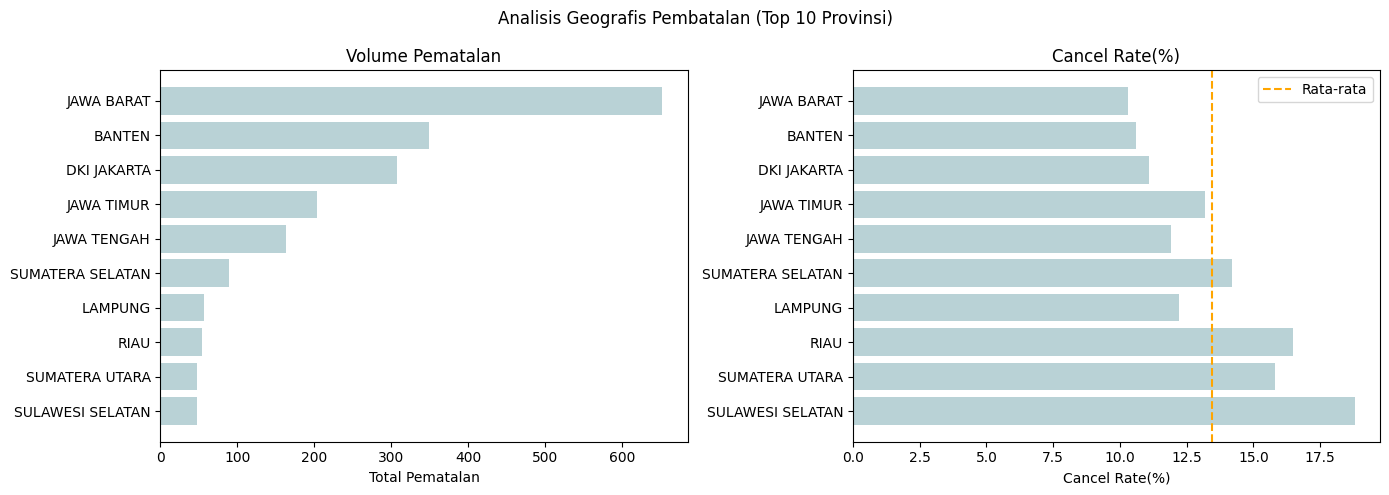

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analisis Geografis Pembatalan (Top 10 Provinsi)")

axes[0].barh(prov_cancel.index[::-1], prov_cancel['Batal'][::-1], alpha=.75, color='#A2C4C9')
axes[0].set_title("Volume Pematalan")
axes[0].set_xlabel("Total Pematalan")

axes[1].barh(prov_cancel.index[::-1], prov_cancel['Cancel Rate'][::-1], alpha=.75, color='#A2C4C9')
axes[1].axvline(prov_cancel['Cancel Rate'].mean(), color='orange', linestyle='--', label='Rata-rata')
axes[1].set_title("Cancel Rate(%)")
axes[1].set_xlabel("Cancel Rate(%)")
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

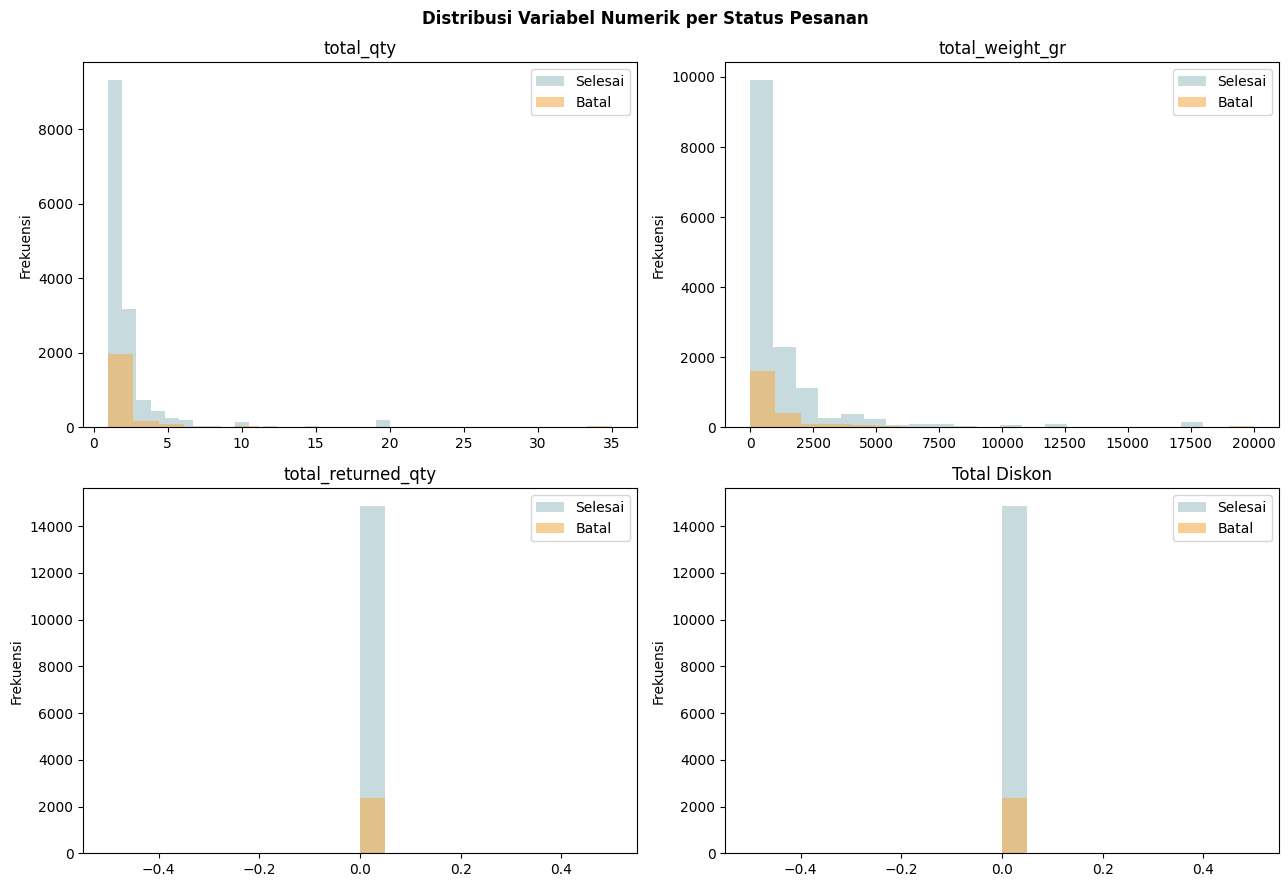

In [59]:
df_plot = df[df['Status Pesanan'].isin(['Selesai', 'Batal'])]

fig, axes = plt.subplots(2,2,figsize=(13,9))
plt.suptitle("Distribusi Variabel Numerik per Status Pesanan", fontweight='bold')

for ax, col in zip(axes.flatten(), ['total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon']):
    for status, color in [('Selesai', '#A2C4C9'), ('Batal', '#F4AE52')]:
        data = df_plot[df_plot['Status Pesanan']==status][col].dropna()
        data_clip = data.clip(upper=data.quantile(.99))
        ax.hist(data_clip, bins=20, alpha=.6, label=status, color=color)
    ax.set_title(col);
    ax.set_ylabel('Frekuensi')
    ax.legend()


plt.tight_layout()
plt.show()

<Axes: >

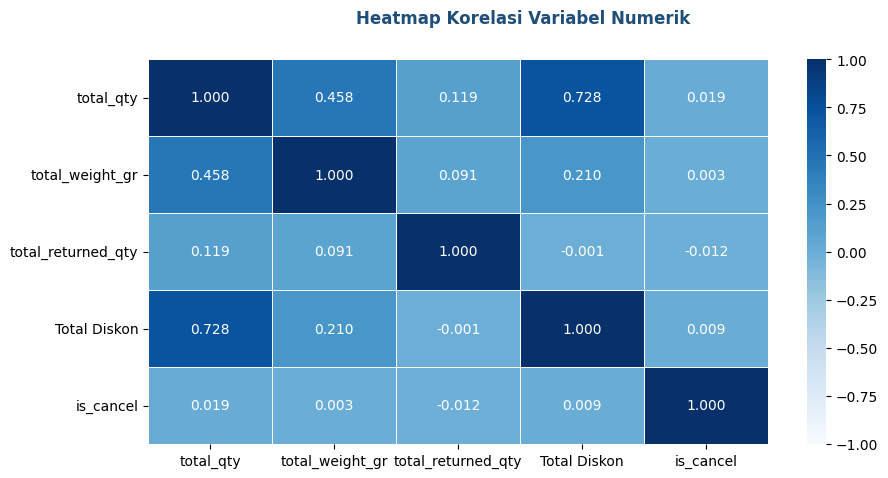

In [46]:
num_corr = df[['total_qty','total_weight_gr','total_returned_qty',
               'Total Diskon','is_cancel']].corr()

fig, axes = plt.subplots(figsize=(10,5))
plt.suptitle('Heatmap Korelasi Variabel Numerik', fontweight='bold', color='#1F4E79')

sns.heatmap(num_corr, annot=True, ax=axes, cmap='Blues', linewidths=.5, fmt='.3f', vmin=-1, vmax=1)